In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USERNAME')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print("Ready")

Ready


In [5]:
df = pd.read_sql("SELECT * FROM food_distribution", engine)

print("Shape:", df.shape)
print(df.head())

Shape: (25, 12)
   distribution_id beneficiary_name  age  gender  province  district  \
0                1     Ahmad Karimi   45    Male     Kabul     Kabul   
1                2     Fatima Noori   32  Female     Kabul     Kabul   
2                3   Mohammad Yusuf   28    Male  Kandahar  Kandahar   
3                4   Zainab Hussain   38  Female     Herat     Herat   
4                5      Abdul Karim   67    Male     Kabul     Kabul   

   food_package_kg distribution_date    enumerator     status  household_size  \
0               25        2024-02-01  Enumerator_A  Completed               6   
1               25        2024-02-01  Enumerator_A  Completed               4   
2              100        2024-02-02  Enumerator_B  Completed               3   
3               25        2024-02-02  Enumerator_B  Completed               5   
4               25        2024-02-03  Enumerator_A  Completed               7   

   monthly_income_usd  
0               120.0  
1               

In [6]:
# Total food distributed per province
# Groupby province and reset province columns that has become index
food_by_province = df.groupby('province')['food_package_kg'].sum().reset_index()
# add descriptive name to columns
food_by_province.columns = ['province', 'total_food_kg']
# sort from big to small total_food_kg
food_by_province = food_by_province.sort_values(
    ['total_food_kg', 'province'],
    ascending=[False, True]
)

print(food_by_province)

   province  total_food_kg
2     Kabul            225
3  Kandahar            225
0     Balkh            125
1     Herat            125


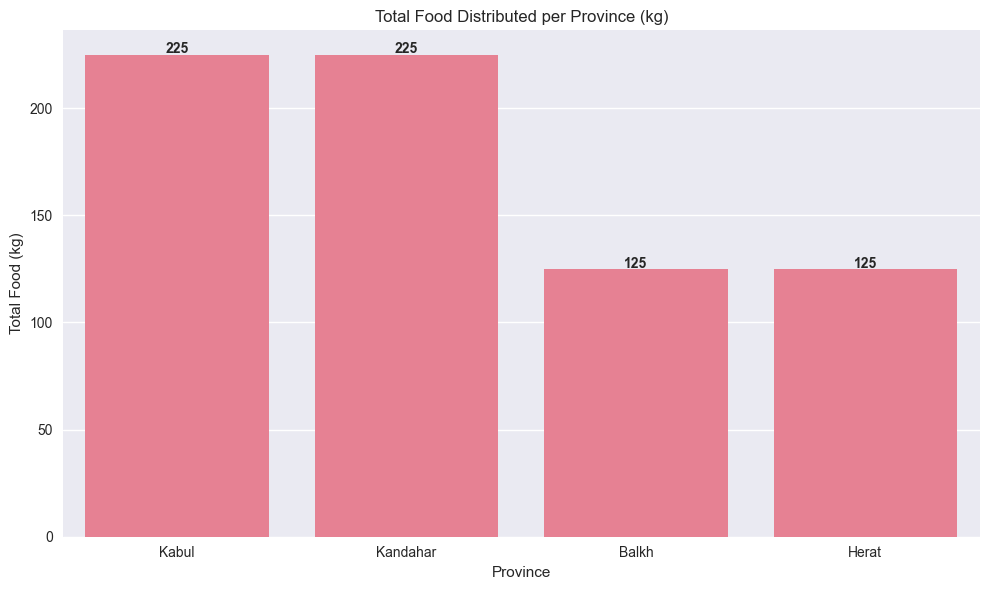

In [7]:
# Visualize
plt.figure()
ax = sns.barplot(data=food_by_province, x='province', y='total_food_kg')
for i, v in enumerate(food_by_province['total_food_kg']):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.title('Total Food Distributed per Province (kg)')
plt.xlabel('Province')
plt.ylabel('Total Food (kg)')
plt.tight_layout()
plt.show()

In [8]:
# In SQL
query = """
SELECT 
    province,
    SUM(food_package_kg) as total_food_kg
FROM food_distribution
GROUP BY province
ORDER BY total_food_kg DESC, province ASC
"""
result = pd.read_sql(query, engine)
print(result)

   province  total_food_kg
0     Kabul          225.0
1  Kandahar          225.0
2     Balkh          125.0
3     Herat          125.0


In [9]:
# Average income and household size by province
# named aggregation agg()
province_summary = df.groupby('province').agg(
    avg_income=('monthly_income_usd', 'mean'),
    avg_household=('household_size', 'mean'),
    beneficiary_count=('beneficiary_name', 'count')
).round(2).reset_index()

province_summary = province_summary.sort_values('avg_income')
print(province_summary)

   province  avg_income  avg_household  beneficiary_count
3  Kandahar       49.17           7.17                  6
0     Balkh       77.00           3.00                  5
1     Herat       86.00           4.40                  5
2     Kabul      124.44           5.44                  9


In [10]:
# SQL - ROUND requires ::numeric
query = """
SELECT 
    province,
    ROUND(AVG(monthly_income_usd)::numeric, 2) as avg_income,
    ROUND(AVG(household_size)::numeric, 2) as avg_household,
    COUNT(beneficiary_name) as beneficiary_count
FROM food_distribution
GROUP BY province
ORDER BY avg_income ASC
"""

result = pd.read_sql(query, engine)
print(result)

   province  avg_income  avg_household  beneficiary_count
0  Kandahar       49.17           7.17                  6
1     Balkh       77.00           3.00                  5
2     Herat       86.00           4.40                  5
3     Kabul      124.44           5.44                  9


In [11]:
# Beneficiary summary by gender
gender_summary = df.groupby('gender').agg(
    count=('beneficiary_name', 'count'),
    avg_age=('age', 'mean'),
    avg_income=('monthly_income_usd', 'mean'),
    avg_household=('household_size', 'mean')
).round(2).reset_index()

print(gender_summary)

   gender  count  avg_age  avg_income  avg_household
0  Female     13    31.38       91.15           3.62
1    Male     12    50.25       87.08           6.83


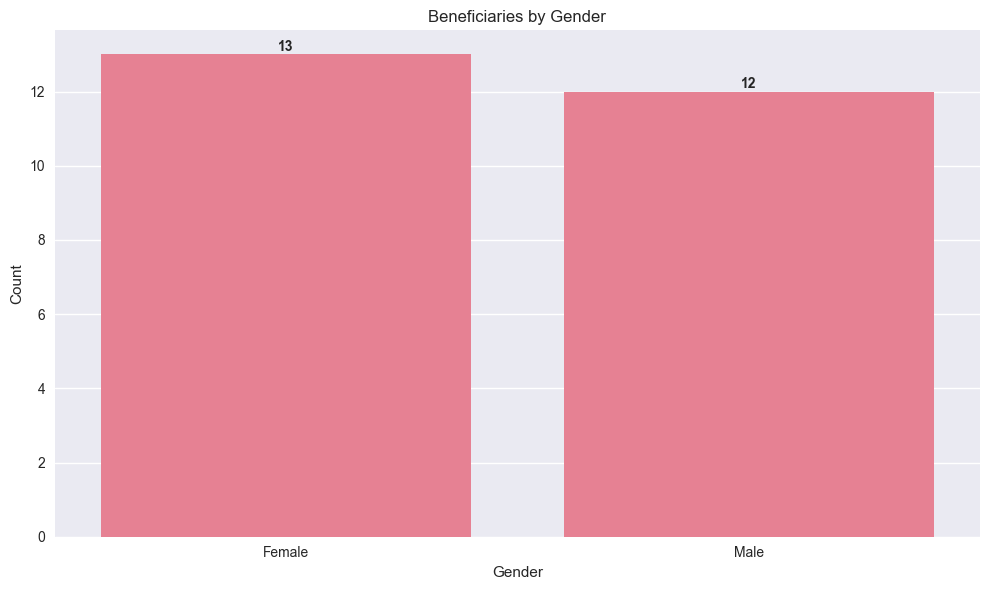

In [12]:
# Visualize count
plt.figure()
ax = sns.barplot(data=gender_summary, x='gender', y='count')
for i, v in enumerate(gender_summary['count']):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.title('Beneficiaries by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [13]:
# SQL
query = """
SELECT
    gender,
    COUNT(beneficiary_name) as count,
    ROUND(AVG(age)::numeric, 2) as avg_age,
    ROUND(AVG(monthly_income_usd)::numeric, 2) as avg_income,
    ROUND(AVG(household_size)::numeric, 2) as avg_household
FROM food_distribution
GROUP BY gender
ORDER BY count DESC
"""

result = pd.read_sql(query, engine)
print(result)

   gender  count  avg_age  avg_income  avg_household
0  Female     13    31.38       91.15           3.62
1    Male     12    50.25       87.08           6.83


In [14]:
# Calculate per capita income
df['income_per_capita'] = df['monthly_income_usd'] / df['household_size']

# Compare by gender
print(df.groupby('gender')['income_per_capita'].mean().round(2))

gender
Female    28.75
Male      14.16
Name: income_per_capita, dtype: float64


In [15]:
query = """
SELECT
    gender,
    ROUND(AVG(monthly_income_usd / household_size)::numeric, 2) as avg_per_capita_income
FROM food_distribution
GROUP BY gender
ORDER BY avg_per_capita_income ASC
"""

result = pd.read_sql(query, engine)
print(result)

   gender  avg_per_capita_income
0    Male                  14.16
1  Female                  28.75


**Findings**  
While total household income showed minimal gender differences, per capita income analysis revealed significant disparity. Male beneficiaries had an average per capita income of $14.16 compared to $28.75 for female beneficiaries, driven by larger average household sizes among male headed households (6 vs 3). This suggests male headed larger households face greater per person economic vulnerability despite similar total incomes, warranting review of targeting and package size criteria.

In [ ]:
# Most vulnerable beneficiaries
# Per capita income
df['income_per_capita'] = df['monthly_income_usd'] / df['household_size']

# Vulnerability score, combines household size and per capita income
df['vulnerability_rank'] = (
    df['household_size'] * 0.4 +
    (1 / df['monthly_income_usd']) * 1000 * 0.6
).round(2)

# Top 5 most vulnerable 
most_vulnerable = df.nlargest(5, 'vulnerability_rank')[ # nlargest -> Equivalent to sort_values(ascending=False).head(5)
    ['beneficiary_name', 'province', 'household_size',
     'monthly_income_usd', 'income_per_capita', 'vulnerability_rank']
]

print("Top 5 Most Vulnerable Beneficiaries:")
print(most_vulnerable)

Top 5 Most Vulnerable Beneficiaries:
   beneficiary_name  province  household_size  monthly_income_usd  \
17    Jawad Sultani  Kandahar              10                40.0   
6     Khalid Ahmadi  Kandahar               9                45.0   
24   Rahimullah Jan  Kandahar               7                45.0   
20    Abdullah Khan  Kandahar               6                50.0   
11  Habibullah Khan  Kandahar               8                55.0   

    income_per_capita  vulnerability_rank  
17           4.000000               19.00  
6            5.000000               16.93  
24           6.428571               16.13  
20           8.333333               14.40  
11           6.875000               14.11  


In [20]:
query = """
SELECT
    beneficiary_name,
    province,
    household_size,
    monthly_income_usd,
    ROUND((monthly_income_usd / household_size)::numeric, 2) as income_per_capita,
    ROUND((household_size * 0.4 + (1.0 / monthly_income_usd) * 1000 * 0.6)::numeric, 2) as vulnerability_rank
FROM food_distribution
ORDER BY vulnerability_rank DESC
LIMIT 5
"""

result = pd.read_sql(query, engine)
print("Top 5 Most Vulnerable Beneficiaries:")
print(result)

Top 5 Most Vulnerable Beneficiaries:
  beneficiary_name  province  household_size  monthly_income_usd  \
0    Jawad Sultani  Kandahar              10                40.0   
1    Khalid Ahmadi  Kandahar               9                45.0   
2   Rahimullah Jan  Kandahar               7                45.0   
3    Abdullah Khan  Kandahar               6                50.0   
4  Habibullah Khan  Kandahar               8                55.0   

   income_per_capita  vulnerability_rank  
0               4.00               19.00  
1               5.00               16.93  
2               6.43               16.13  
3               8.33               14.40  
4               6.88               14.11  
